### 2) Sensitivity sweep on superconducting QPU baseline power (not using in our paper)

This is a post-processing sensitivity sweep on the existing job records.

That gives us the same timing trace, and we just recompute:

$$
E_{\text{qpu}} = \sum_i P_{\text{qpu}} \cdot \frac{t_i}{3600}
\quad\Rightarrow\quad
\text{Cost} = (E_{\text{qpu}} + E_{\text{cpu}})\cdot \pi
$$

Below is code that:
- 1.	takes your job_records
- 2.	sweeps QPU baseline power
- 3.	computes avg cost/job (and p95) for each scenario
- 4.	plots the sensitivity curve

⸻

✅ Post-processing sensitivity sweep (recommended)

What it assumes
- You already ran sim_env.run()
- Your records contain either:
- qpu_time_s and/or qpu_segments with per-segment time_s
- CPU energy is already computed correctly (or we can keep CPU constant across sweeps)


cpu_power_model: affine
default_cpu_idle_kw: 0.22
2 QPU(s), 2 CPU(s)
0.00: SIMULATION STARTED
3227.43: SIMULATION ENDED
Number of jobs processed: 5000
Job:  0
QPU time (s): 8.9092
CPU time (s): 2.8443
Energy (kWh): 0.1648
Cost ($): 0.0297

QPU_kW, mean_cost, p95_cost, median_cost
    25, 0.010888, 0.020854, 0.009838
    50, 0.021183, 0.040806, 0.019118
    80, 0.033537, 0.064750, 0.030269
   100, 0.041773, 0.080712, 0.037710
   140, 0.058245, 0.112636, 0.052614


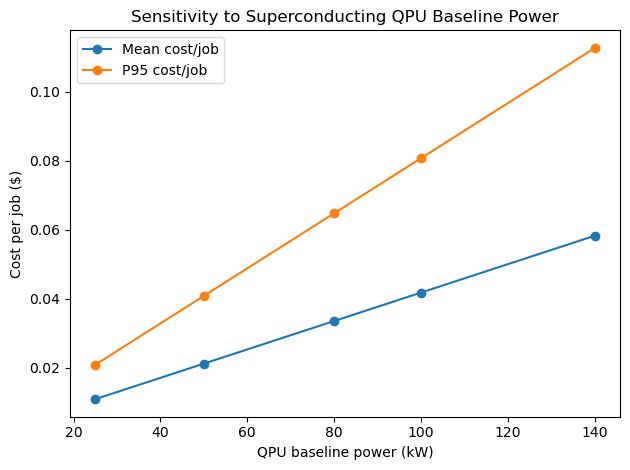

In [4]:

from HybridCloud import *
import numpy as np
import matplotlib.pyplot as plt

PRINTLOG = False
# Devices
ibm_strasbourg = IBM_Strasbourg(env=None, name="QPU-1", printlog = PRINTLOG)
ibm_brussels = IBM_Brussels(env=None, name="QPU-2", printlog = PRINTLOG)
# ibm_marrakesh = IBM_Marrakesh(env=None, name="QPU-3", printlog = PRINTLOG)
# ibm_quebec = IBM_Quebec(env=None, name="QPU-4", printlog = PRINTLOG)
ryzen1 = AMDRyzen("CPU-1", env=None)
ryzen2 = AMDRyzen("CPU-2", env=None)

cost_config = {
  "energy": {
    "electricity_price_per_kwh": 0.18,
    "default_qpu_power_kw": 50.0,
    "qpu_power_kw": {"QPU-1": 70.0, "QPU-2": 60.0},
    "cpu_power_kw": {"CPU-1": 5.0, "CPU-2": 6.5},
    "cpu_power_model": "affine",
    "default_cpu_idle_kw": 0.22,
    "default_cpu_peak_kw": 0.75,
    "default_cpu_capacity_units": 16,
    "debug_energy": False
  }
}


# Hybrid environment
sim_env = HybridCloudSimEnv(
    qpu_devices = [ibm_strasbourg, ibm_brussels],
    cpu_devices = [ryzen1, ryzen2],
    broker_class = HybridBroker,
    job_feed_method = 'dispatcher',
    file_path = 'synth_job_batches/5000-job.csv', 
    job_generation_model = None, 
    printlog = PRINTLOG, 
    cost_config=cost_config
)


print(f"cpu_power_model: {sim_env.cost_config['energy']['cpu_power_model']}")
print(f"default_cpu_idle_kw: {sim_env.cost_config['energy']['default_cpu_idle_kw']}")

sim_env.run()

rec = sim_env.job_records_manager.get_job_records()
for i in range(0, 1): 
    print("Job: ", i)
    print("QPU time (s):", rec[i]["qpu_time_s"])
    print("CPU time (s):", rec[i]["cpu_time_s"])
    print("Energy (kWh):", rec[i]["energy_total_kwh"])
    print("Cost ($):", rec[i]["cost_energy_total"])
    print("")
    
def recompute_cost_for_qpu_power(job_records, qpu_power_kw, electricity_price_per_kwh=0.18):
    """
    Recompute per-job total cost under a *uniform* QPU baseline power (kW),
    keeping CPU energy as-is from the record.
    Returns list of per-job costs.
    """
    costs = []

    for job_id, rec in job_records.items():
        # CPU energy stays unchanged across QPU power sweep
        e_cpu = float(rec.get("energy_cpu_kwh", 0.0) or 0.0)

        # Compute QPU energy from segments if available; fallback to qpu_time_s
        if "qpu_segments" in rec and rec["qpu_segments"]:
            qpu_time_s_total = sum(float(seg.get("time_s", 0.0) or 0.0) for seg in rec["qpu_segments"])
        else:
            qpu_time_s_total = float(rec.get("qpu_time_s", 0.0) or 0.0)

        e_qpu = qpu_power_kw * (qpu_time_s_total / 3600.0)

        e_total = e_qpu + e_cpu
        cost = e_total * electricity_price_per_kwh
        costs.append(cost)

    return costs

def summarize(costs):
    costs = np.array(costs, dtype=float)
    return {
        "mean": float(costs.mean()),
        "median": float(np.median(costs)),
        "p95": float(np.percentile(costs, 95)),
    }

def sweep_qpu_power(job_records, powers_kw, electricity_price_per_kwh=0.18):
    results = []
    for p in powers_kw:
        costs = recompute_cost_for_qpu_power(job_records, p, electricity_price_per_kwh)
        s = summarize(costs)
        results.append((p, s["mean"], s["p95"], s["median"]))
    return results

def plot_sweep(results):
    powers = [r[0] for r in results]
    means  = [r[1] for r in results]
    p95s   = [r[2] for r in results]

    plt.figure()
    plt.plot(powers, means, marker="o", label="Mean cost/job")
    plt.plot(powers, p95s, marker="o", label="P95 cost/job")
    plt.xlabel("QPU baseline power (kW)")
    plt.ylabel("Cost per job ($)")
    plt.title("Sensitivity to Superconducting QPU Baseline Power")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ---- Run after sim_env.run() ----
job_records = sim_env.job_records_manager.job_records

powers_kw = [25, 50, 80, 100, 140]  # choose your sweep set
results = sweep_qpu_power(job_records, powers_kw, electricity_price_per_kwh=0.18)

print("QPU_kW, mean_cost, p95_cost, median_cost")
for p, mean_c, p95_c, med_c in results:
    print(f"{p:>6}, {mean_c:.6f}, {p95_c:.6f}, {med_c:.6f}")

plot_sweep(results)

QPU_kW, mean_cost, p95_cost, median_cost
    25, 0.010888, 0.020854, 0.009838
    50, 0.021183, 0.040806, 0.019118
    80, 0.033537, 0.064750, 0.030269
   100, 0.041773, 0.080712, 0.037710
   140, 0.058245, 0.112636, 0.052614


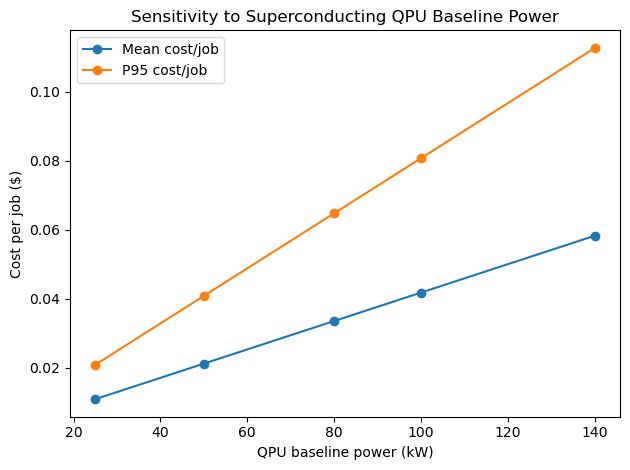

In [5]:
def recompute_cost_with_scaled_qpu_map(job_records, base_map_kw, scale, electricity_price_per_kwh=0.18):
    costs = []
    for job_id, rec in job_records.items():
        e_cpu = float(rec.get("energy_cpu_kwh", 0.0) or 0.0)
        e_qpu = 0.0

        # qpu_segments contain device + time_s
        for seg in rec.get("qpu_segments", []):
            dev = seg.get("device")
            t_s = float(seg.get("time_s", 0.0) or 0.0)
            p_kw = base_map_kw.get(dev, 0.0) * scale
            e_qpu += p_kw * (t_s / 3600.0)

        cost = (e_qpu + e_cpu) * electricity_price_per_kwh
        costs.append(cost)
    return costs

def summarize(costs):
    costs = np.array(costs, dtype=float)
    return {
        "mean": float(costs.mean()),
        "median": float(np.median(costs)),
        "p95": float(np.percentile(costs, 95)),
    }

def sweep_qpu_power(job_records, powers_kw, electricity_price_per_kwh=0.18):
    results = []
    for p in powers_kw:
        costs = recompute_cost_for_qpu_power(job_records, p, electricity_price_per_kwh)
        s = summarize(costs)
        results.append((p, s["mean"], s["p95"], s["median"]))
    return results

def plot_sweep(results):
    powers = [r[0] for r in results]
    means  = [r[1] for r in results]
    p95s   = [r[2] for r in results]

    plt.figure()
    plt.plot(powers, means, marker="o", label="Mean cost/job")
    plt.plot(powers, p95s, marker="o", label="P95 cost/job")
    plt.xlabel("QPU baseline power (kW)")
    plt.ylabel("Cost per job ($)")
    plt.title("Sensitivity to Superconducting QPU Baseline Power")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ---- Run after sim_env.run() ----
job_records = sim_env.job_records_manager.job_records

powers_kw = [25, 50, 80, 100, 140]  # choose your sweep set
results = sweep_qpu_power(job_records, powers_kw, electricity_price_per_kwh=0.18)

print("QPU_kW, mean_cost, p95_cost, median_cost")
for p, mean_c, p95_c, med_c in results:
    print(f"{p:>6}, {mean_c:.6f}, {p95_c:.6f}, {med_c:.6f}")

plot_sweep(results)

Then sweep scale instead of raw kW.

When you do need to rerun the simulator

Only rerun if:
	•	your scheduler/broker will choose devices based on energy/cost, or
	•	power model influences runtime (it currently doesn’t).

For this paper’s Experiment 2, post-processing is the right approach.

⸻

What to report in the manuscript

For each power setting:
	•	mean cost/job
	•	p95 cost/job
	•	(optional) mean energy/job (kWh)

And one figure:
	•	line plot: QPU baseline power (kW) → mean cost/job

⸻

If you paste a snippet of one record’s qpu_segments after your CPU fix (just to confirm the keys), I’ll tailor the sweep code to exactly match your structure (but the above should work with what you showed).